# Notebook 2: Merge Pipeline — ACLED Events + CAST Risk Indicators

## Purpose
This notebook **merges the base ACLED event dataset with CAST early-warning risk
indicators** and runs a quick head-to-head evaluation to check whether the 7 new
signals improve RF forecast accuracy.

## Datasets
| Dataset | Path | Description |
|---------|------|-------------|
| Input 1 | `data/processed/model_data.csv` | 31 original ACLED predictors + 3 targets |
| Input 2 | `data/raw/master_raw.csv` | CAST risk signal archive (raw, monthly, country-level) |
| Output | `data/processed/model_risk_merged.csv` | 38 predictors — baseline + 7 lagged risk indicators |

## What are the risk indicators?
The 7 CAST signals are discrete event counts per country-month for:
`risk_contested_election`, `risk_crop_failure`, `risk_economic_concern`,
`risk_ethnic_tension`, `risk_military_coup`, `risk_natural_disaster`,
`risk_political_assassination`

Each is lagged by **t-1** before joining to prevent data leakage: we only use
signals that would have been observable at the time of the forecast.

## Model used for evaluation
A single **Random Forest (100 trees, seed=42)** with chronological 6-month hold-out.
We compare:
- **Baseline** — 31 original predictors
- **Enhanced** — 31 + 7 lagged risk indicators (38 total)

> The labels "Baseline" and "Enhanced" in this notebook refer only to this
> risk-indicator comparison. The 9-feature engineered set (lag-2, rolling averages,
> etc.) is a separate step built in `feature_engineering.ipynb`.

## What this notebook does
1. Merges via `utils/risk_merge.RiskIndicatorMerger`
2. Identifies the 10 most conflict-active regions
3. Trains and evaluates Baseline vs Enhanced for Battles and Violence against civilians
4. Plots MAE bar charts, forecast line plots, and risk feature importances
5. Saves `model_risk_merged.csv` → picked up by `feature_engineering.ipynb`


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # project root → finds config/ and utils/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import settings
from utils.risk_merge import RiskIndicatorMerger

# Evaluation and plotting utilities — see utils/evaluators.py and utils/visualization.py
from utils.evaluators import (
    find_top_regions,
    ModelEvaluator,
    run_comparison,
    build_comparison_table,
)
from utils.visualization import (
    plot_mae_comparison,
    plot_forecasts,
    plot_risk_feature_importance,
)

os.makedirs("../outputs/figures", exist_ok=True)
FIGURES = "../outputs/figures"
print("All imports OK.")


All imports OK.


---
## Step 1: Build the Risk-Merged Dataset

We use `RiskIndicatorMerger` (see `utils/risk_merge.py`) to join the base ACLED
dataset with 7 CAST early-warning signals from `master_raw.csv`.

Each risk indicator is **lagged by one month (t-1)** before joining. This ensures
we are only using information that would have been available at forecast time —
a critical requirement for any honest time-series evaluation. Using the current
month's risk signal to predict the current month's violence would constitute
data leakage.

The 7 indicators added:
- risk_contested_election, risk_crop_failure, risk_economic_concern
- risk_ethnic_tension, risk_military_coup, risk_natural_disaster
- risk_political_assassination

In [2]:
MODEL_DATA_PATH = "../data/processed/model_data.csv"
MASTER_RAW_PATH = "../data/raw/master_raw.csv"

merger    = RiskIndicatorMerger(lag=1)
merged_df = merger.merge(MODEL_DATA_PATH, MASTER_RAW_PATH)

baseline_preds = settings.predictors
enhanced_preds = merger.get_enhanced_predictors()

print(f"Base dataset : {pd.read_csv(MODEL_DATA_PATH).shape}  —  {len(baseline_preds)} predictors")
print(f"Merged dataset: {merged_df.shape}  —  {len(enhanced_preds)} predictors")
print(f"\nRisk indicators added (lagged t-1):")
for col in merger.risk_cols_lagged_:
    print(f"  {col}")

lagged_mask = merged_df[merger.risk_cols_lagged_].sum(axis=1) > 0
print(f"\nRows with any lagged risk signal: "
      f"{lagged_mask.sum():,} / {len(merged_df):,} ({lagged_mask.mean()*100:.1f}%)")

Base dataset : (289890, 36)  —  30 predictors
Merged dataset: (289890, 51)  —  37 predictors

Risk indicators added (lagged t-1):
  risk_contested_election (t-1)
  risk_crop_failure (t-1)
  risk_economic_concern (t-1)
  risk_ethnic_tension (t-1)
  risk_military_coup (t-1)
  risk_natural_disaster (t-1)
  risk_political_assassination (t-1)

Rows with any lagged risk signal: 150,130 / 289,890 (51.8%)


In [3]:
# Preview: rows where at least one risk indicator fired last month
preview_cols = (["matched_admin1_id", "month_year"]
                + merger.risk_cols_lagged_
                + settings.targets)
sample = merged_df[lagged_mask][preview_cols].head(15)
display(sample)

,matched_admin1_id,month_year,risk_contested_election (t-1),risk_crop_failure (t-1),risk_economic_concern (t-1),risk_ethnic_tension (t-1),risk_military_coup (t-1),risk_natural_disaster (t-1),risk_political_assassination (t-1),Battles,Explosions/Remote violence,Violence against civilians
26,ABW - Aruba,2020-03-01,2,0,0,0,0,0,0,0,0,0
33,ABW - Aruba,2020-10-01,0,0,1,0,0,2,0,0,0,0
34,ABW - Aruba,2020-11-01,0,0,1,0,0,2,0,0,0,0
37,ABW - Aruba,2021-02-01,0,0,1,0,0,2,0,0,0,0
49,ABW - Aruba,2022-02-01,0,0,0,0,0,0,1,0,0,0
79,ABW - Aruba,2024-08-01,0,0,0,0,0,0,1,0,0,0
81,ABW - Aruba,2024-10-01,1,0,0,0,0,0,0,0,0,0
82,ABW - Aruba,2024-11-01,0,0,0,0,0,1,0,0,0,0
85,ABW - Aruba,2025-02-01,0,0,1,0,0,0,0,0,0,1
86,ABW - Aruba,2025-03-01,1,0,0,0,0,13,0,0,0,0


---
## Step 2: Identify the 10 Most Active Regions

We evaluate only the top-10 regions by total event count. This is not because
other regions are unimportant — it is because they are dominated by zeros, making
MAE comparisons between feature sets statistically uninformative. Regions like
Donetsk, Gaza, or Idlib provide the richest signal for testing whether new
features genuinely help the model.

In [4]:
top_10 = find_top_regions(merged_df, settings.targets, n=10)

activity = (
    merged_df[merged_df["matched_admin1_id"].isin(top_10)]
    .groupby("matched_admin1_id")[settings.targets]
    .sum()
)
activity["Total"] = activity.sum(axis=1)
activity = activity.sort_values("Total", ascending=False)

print("Top 10 most active regions (total events 2018–2025):\n")
display(activity)

Top 10 most active regions (total events 2018–2025):



,Battles,Explosions/Remote violence,Violence against civilians,Total
matched_admin1_id,,,,
UKR - Donetsk,48118,55161,139,103418
UKR - Kharkiv,6234,17367,205,23806
UKR - Sumy,362,21908,31,22301
SYR - Idlib,2624,18614,925,22163
PSX - Gaza,1700,18714,589,21003
UKR - Kherson,2462,17503,336,20301
BRA - Rio de Janeiro,17594,69,2359,20022
SYR - Aleppo,4427,12501,2445,19373
UKR - Zaporizhzhia,3070,14787,196,18053


---
## Step 3: Performance Comparison — Baseline vs Enhanced

For each region × target combination we train **two** Random Forest models:

- **Baseline**: 31 predictors from `settings.predictors` (lagged event counts,
  neighbour aggregates, temporal dummies, importance weight)
- **Enhanced**: 38 predictors — baseline + **7 lagged CAST risk indicators**
  added by `RiskIndicatorMerger` in Step 1

> **Note on naming:** The "Enhanced" label in this notebook refers only to the
> 7 CAST risk indicator columns (`risk_contested_election (t-1)`, etc.). It is
> **not** the same as the 9-feature engineered set (lag-2, rolling averages,
> interaction terms) that is built separately in `feature_engineering.ipynb`
> using `utils/data_cleaning.build_enhanced_features()`. That broader feature
> set is used in the final ablation benchmark in `model_comparison.ipynb`.

Both models use:
- The same chronological train/test split (last 6 months held out)
- The same RF hyperparameters (100 trees, seed=42)
- Importance-weighted training (more recent months count more)

Because conflict data has strong temporal autocorrelation, we never shuffle
the data or use cross-validation — that would leak future information into
training and give artificially optimistic results.

In [5]:
evaluator = ModelEvaluator(n_estimators=100, holdout_months=6)

TARGET = "Battles"
results_battles = run_comparison(
    merged_df, top_10, TARGET, baseline_preds, enhanced_preds, evaluator
)

table_battles = build_comparison_table(results_battles)
display(table_battles)

avg_b = table_battles["MAE Baseline"].mean()
avg_e = table_battles["MAE Enhanced"].mean()
print(f"\nAverage MAE — Baseline: {avg_b:.2f}  |  Enhanced: {avg_e:.2f}")
print(f"Regions where Enhanced wins: {(table_battles['MAE Diff'] > 0).sum()}/{len(table_battles)}")
print(f"Overall MAE change: {((avg_e - avg_b) / avg_b * 100):+.1f}%")

,MAE Baseline,MAE Enhanced,MAE Diff,MAE % Change,MAPE Baseline,MAPE Enhanced
region,,,,,,
PSX - Gaza,38.96,35.69,3.27,-8.4,938.86,896.32
UKR - Zaporizhzhia,40.02,38.91,1.11,-2.8,35.96,35.17
UKR - Kherson,10.43,9.44,0.99,-9.5,16.11,14.55
UKR - Donetsk,265.07,265.36,-0.29,0.1,18.55,18.50
BRA - Rio de Janeiro,19.87,20.43,-0.56,2.8,11.36,11.80
UKR - Luhansk,33.36,34.20,-0.84,2.5,63.79,65.32
UKR - Kharkiv,33.04,33.89,-0.85,2.6,11.12,11.40
UKR - Sumy,40.15,41.02,-0.87,2.2,73.66,81.67
SYR - Aleppo,50.46,52.57,-2.11,4.2,416.82,439.97



Average MAE — Baseline: 56.11  |  Enhanced: 56.45
Regions where Enhanced wins: 3/10
Overall MAE change: +0.6%


In [6]:
TARGET_2 = "Violence against civilians"
results_vac = run_comparison(
    merged_df, top_10, TARGET_2, baseline_preds, enhanced_preds, evaluator
)

table_vac = build_comparison_table(results_vac)
display(table_vac)

avg_b2 = table_vac["MAE Baseline"].mean()
avg_e2 = table_vac["MAE Enhanced"].mean()
print(f"\nAverage MAE — Baseline: {avg_b2:.2f}  |  Enhanced: {avg_e2:.2f}")
print(f"Regions where Enhanced wins: {(table_vac['MAE Diff'] > 0).sum()}/{len(table_vac)}")
print(f"Overall MAE change: {((avg_e2 - avg_b2) / avg_b2 * 100):+.1f}%")

,MAE Baseline,MAE Enhanced,MAE Diff,MAE % Change,MAPE Baseline,MAPE Enhanced
region,,,,,,
BRA - Rio de Janeiro,3.73,3.19,0.54,-14.5,16.29,13.68
PSX - Gaza,16.12,15.82,0.30,-1.9,62.27,60.42
UKR - Sumy,1.28,1.01,0.27,-21.1,NaN,NaN
UKR - Donetsk,2.82,2.59,0.23,-8.2,140.42,126.33
SYR - Aleppo,19.39,19.17,0.22,-1.1,107.81,106.14
UKR - Kherson,1.42,1.32,0.10,-7.0,NaN,NaN
UKR - Zaporizhzhia,0.79,0.75,0.04,-5.1,45.50,17.50
UKR - Luhansk,0.36,0.38,-0.02,5.6,65.00,57.00
UKR - Kharkiv,1.27,1.35,-0.08,6.3,96.75,88.75



Average MAE — Baseline: 5.36  |  Enhanced: 5.28
Regions where Enhanced wins: 7/10
Overall MAE change: -1.5%


---
## Step 4: Visualisations

**MAE bar charts**: side-by-side Baseline vs Enhanced MAE per region — shorter bars are better.

**Forecast line plots**: for each region, the actual held-out values (black solid line)
are shown alongside both the Baseline prediction (blue dashed) and Enhanced prediction
(orange dashed). When the orange line is closer to black than the blue line, the risk
indicators helped. The MAE for each model is shown in the legend.

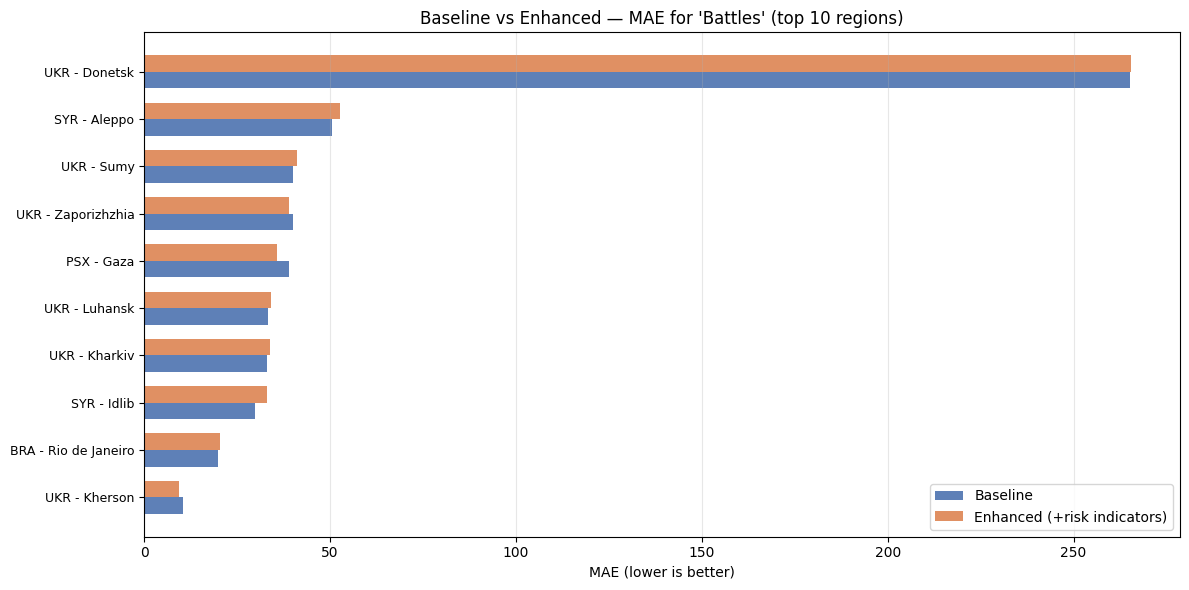

In [7]:
plot_mae_comparison(results_battles, "Battles",
                    save_path=f"{FIGURES}/mae_battles.png")


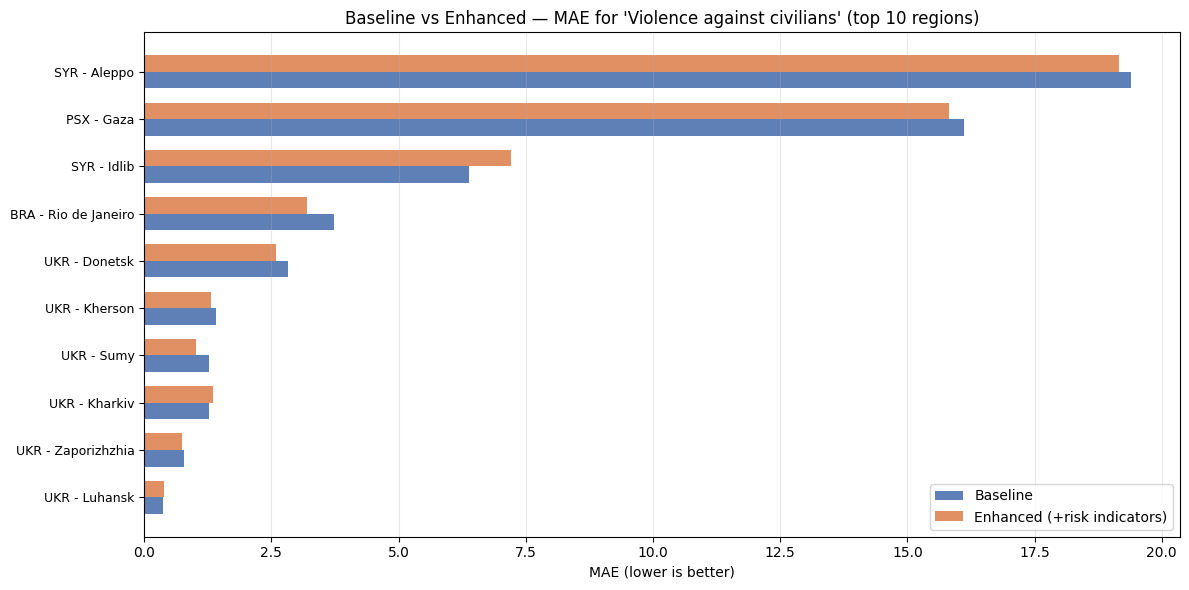

In [8]:
plot_mae_comparison(results_vac, "Violence against civilians",
                    save_path=f"{FIGURES}/mae_vac.png")


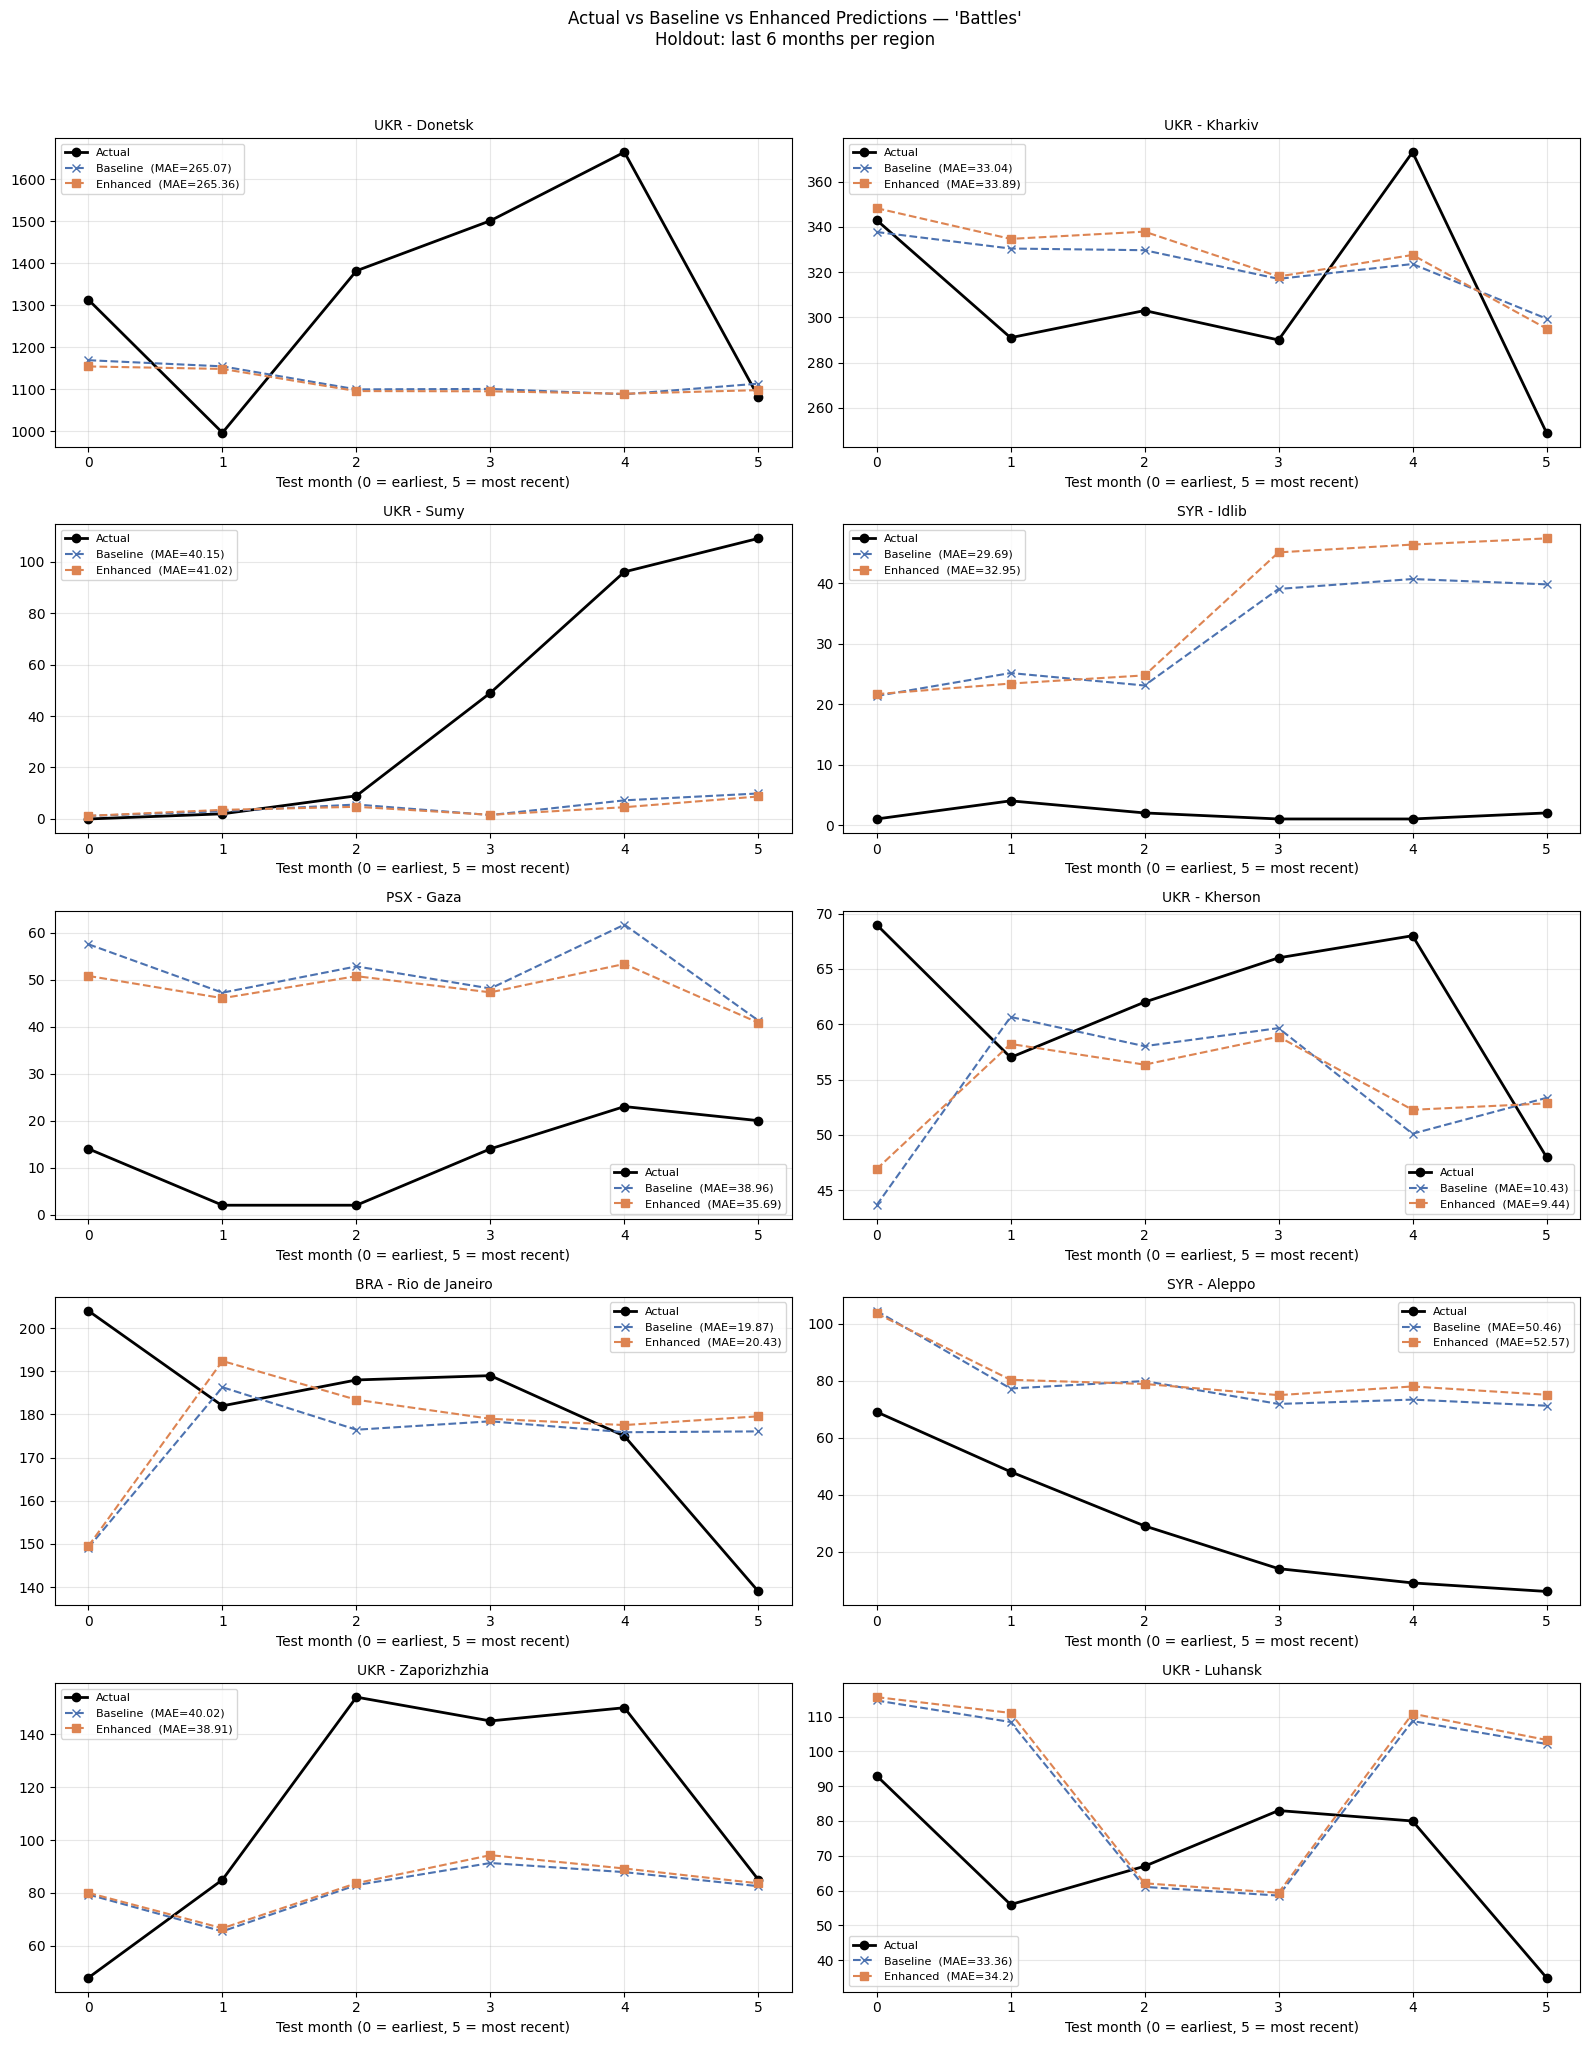

In [9]:
# Each subplot shows Actual (black), Baseline (blue), Enhanced (orange).
# Month 0 is the earliest hold-out month; month 5 is the most recent.
plot_forecasts(results_battles, "Battles",
               save_path=f"{FIGURES}/forecast_battles.png")


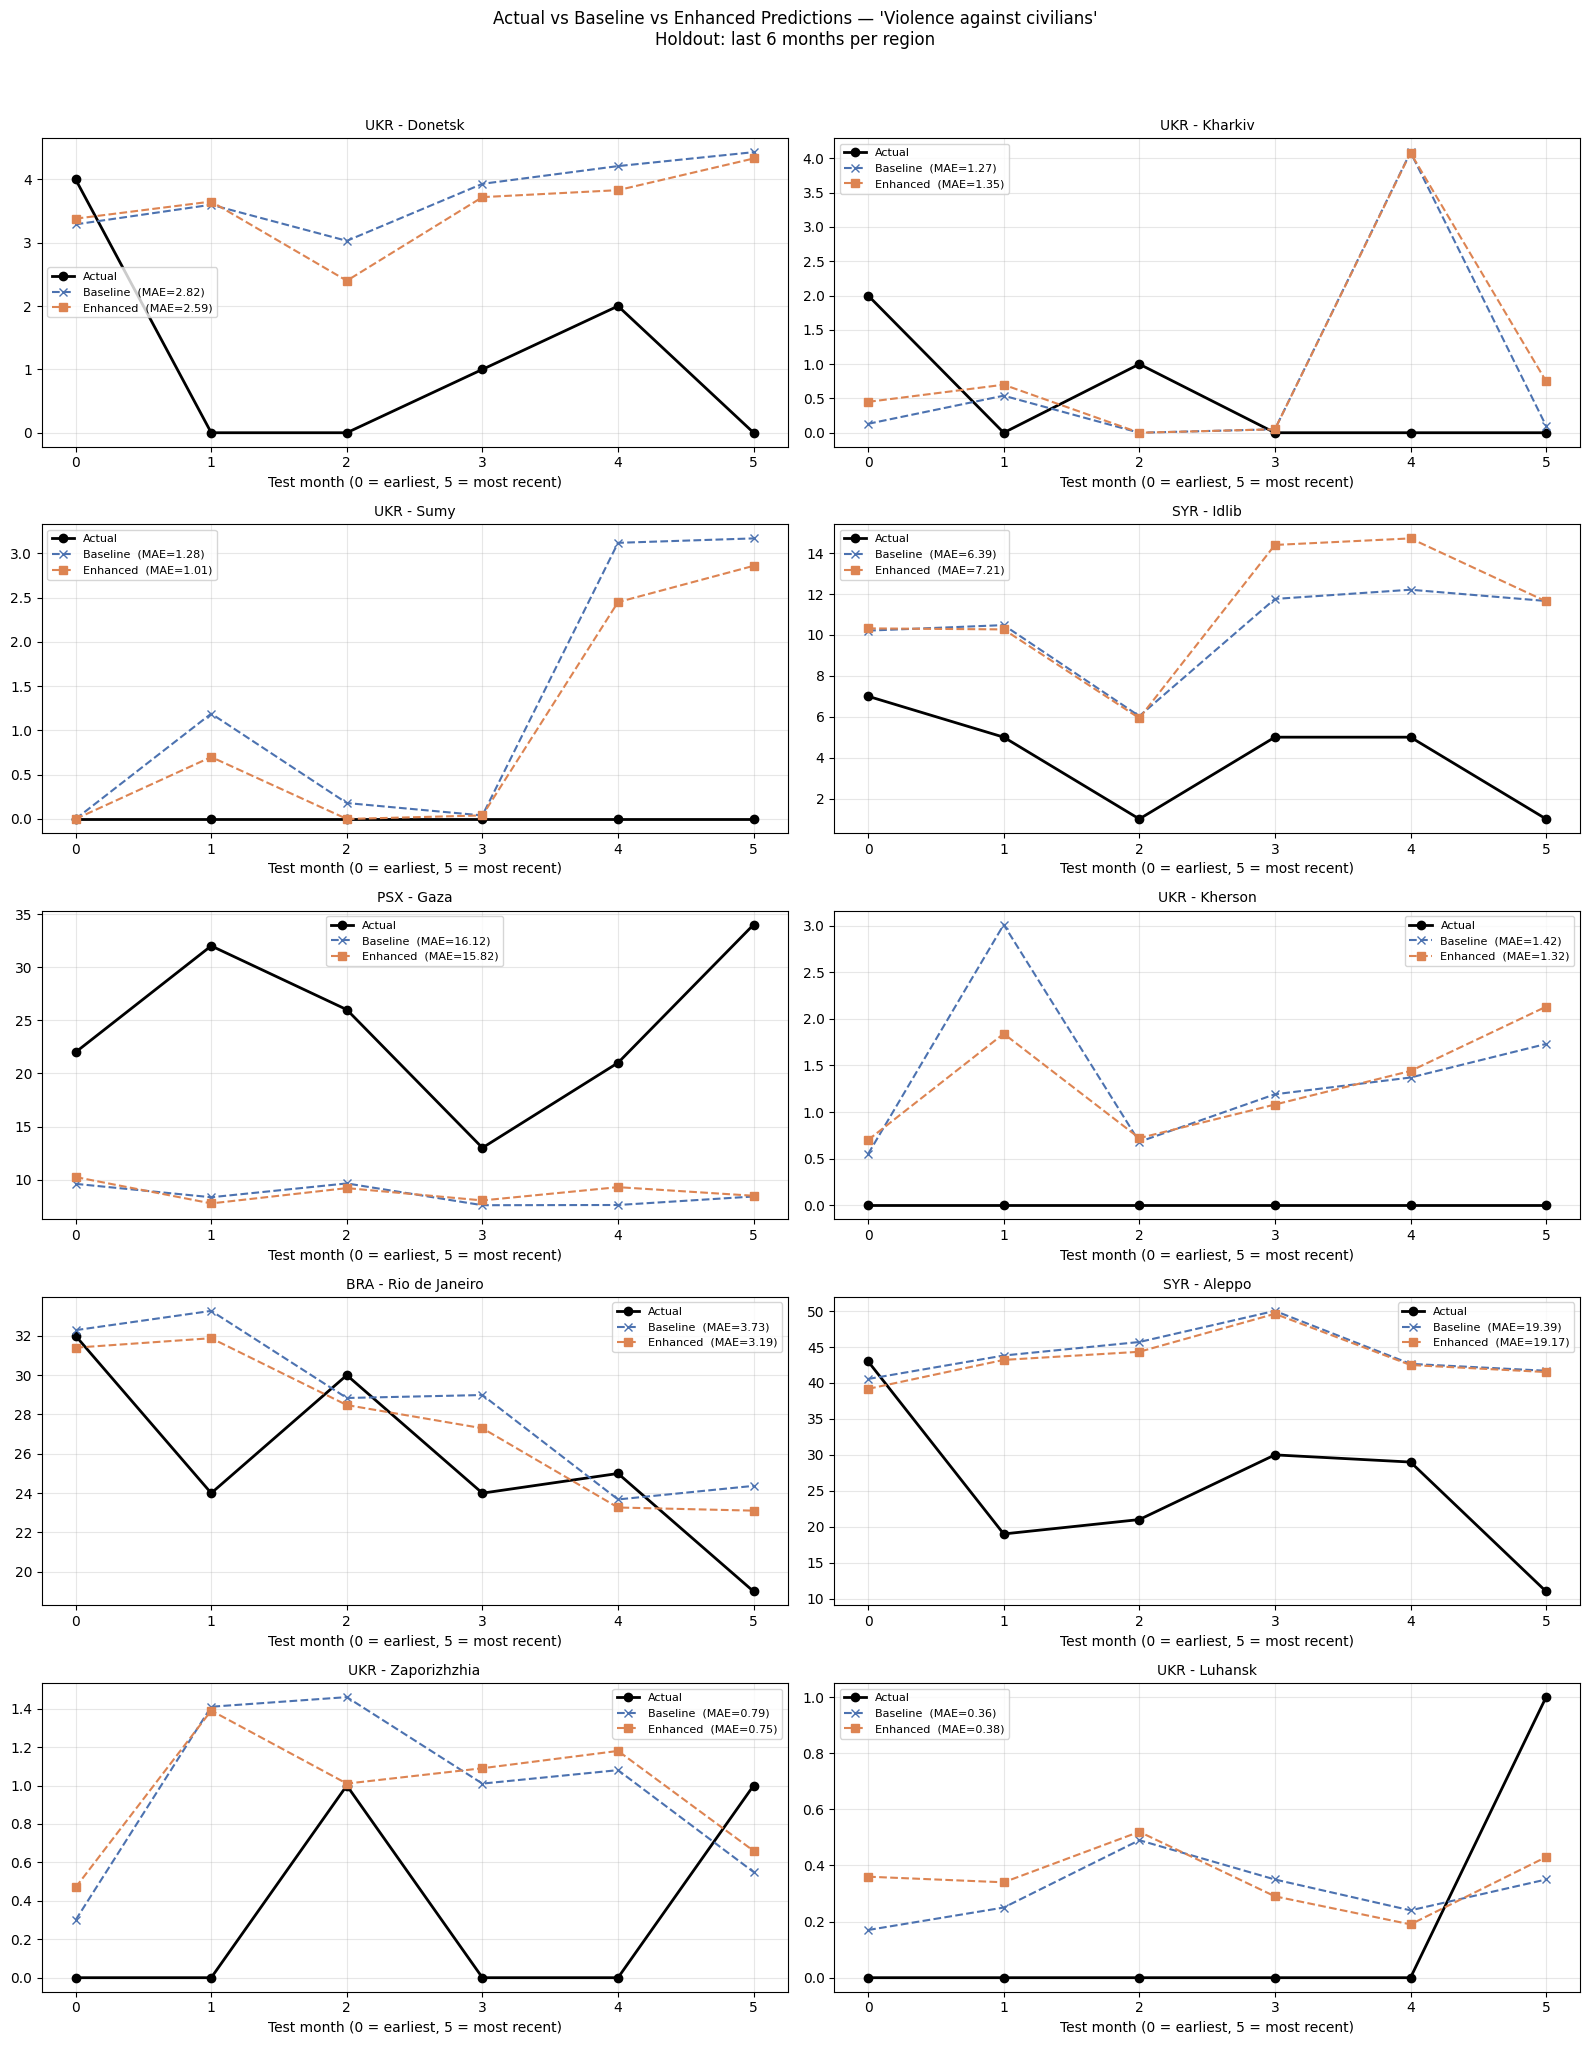

In [10]:
plot_forecasts(results_vac, "Violence against civilians",
               save_path=f"{FIGURES}/forecast_vac.png")


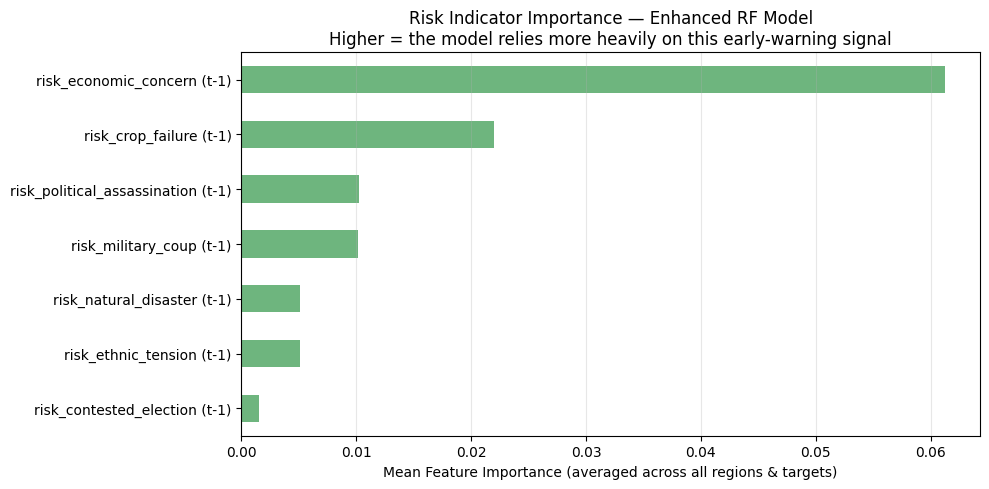

In [11]:
# Which risk indicators does the Enhanced model rely on most?
# Importances are averaged across all regions and both targets.
all_results = pd.concat([results_battles, results_vac], ignore_index=True)
plot_risk_feature_importance(all_results,
                             save_path=f"{FIGURES}/risk_feature_importance.png")


---
## Step 5: Summary

Interpretation guide:
- A small positive or negative change in overall MAE (~2–3%) is within the noise
  for a 6-month, 10-region evaluation — it does not mean risk indicators are useless.
- Look instead at the **per-region** breakdown: some zones (e.g. Kherson) show
  meaningful improvement while others are neutral or slightly worse.
- The feature importance chart reveals which signals the model actually uses.

Next step: `feature_engineering.ipynb` adds macro economic indicators, public
holiday counts, and 9 engineered features, then saves the full merged dataset
for the ablation benchmark in `model_comparison.ipynb`.

In [12]:
print("=" * 70)
print("OVERALL SUMMARY — Risk Indicators Merge")
print("=" * 70)

rows = []
for tname, table in [("Battles", table_battles), ("Violence against civilians", table_vac)]:
    avg_b = table["MAE Baseline"].mean()
    avg_e = table["MAE Enhanced"].mean()
    rows.append({
        "Target":              tname,
        "Regions tested":      len(table),
        "Regions improved":    (table["MAE Diff"] > 0).sum(),
        "Avg MAE (Baseline)":  round(avg_b, 2),
        "Avg MAE (Enhanced)":  round(avg_e, 2),
        "MAE Change %":        f"{(avg_e - avg_b) / avg_b * 100:+.1f}%",
    })
display(pd.DataFrame(rows).set_index("Target"))

print("\nPredictor sets:")
print(f"  Baseline:  {len(baseline_preds)} features")
print(f"  Enhanced:  {len(enhanced_preds)} features (+{len(merger.risk_cols_lagged_)} lagged risk indicators)")
print("\nRisk indicators added:")
for c in merger.risk_cols_lagged_:
    print(f"  - {c}")

OVERALL SUMMARY — Risk Indicators Merge


,Regions tested,Regions improved,Avg MAE (Baseline),Avg MAE (Enhanced),MAE Change %
Target,,,,,
Battles,10,3,56.10,56.45,+0.6%
Violence against civilians,10,7,5.36,5.28,-1.5%



Predictor sets:
  Baseline:  30 features
  Enhanced:  37 features (+7 lagged risk indicators)

Risk indicators added:
  - risk_contested_election (t-1)
  - risk_crop_failure (t-1)
  - risk_economic_concern (t-1)
  - risk_ethnic_tension (t-1)
  - risk_military_coup (t-1)
  - risk_natural_disaster (t-1)
  - risk_political_assassination (t-1)


In [13]:
# ── Save risk-merged dataset ───────────────────────────────────────────────
# feature_engineering.ipynb loads this file as its starting point.
# It adds three more feature layers on top of this dataset.

SAVE_PATH = "../data/processed/model_risk_merged.csv"
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
merged_df.to_csv(SAVE_PATH, index=False)
print(f"Saved: {SAVE_PATH}")
print(f"Shape: {merged_df.shape[0]:,} rows x {merged_df.shape[1]} cols")
print(f"Columns: {list(merged_df.columns)}")

Saved: ../data/processed/model_risk_merged.csv
Shape: 289,890 rows x 51 cols
Columns: ['matched_admin1_id', 'month_year', 'Battles (t-1)', 'Explosions/Remote violence (t-1)', 'Protests (t-1)', 'Riots (t-1)', 'Strategic developments (t-1)', 'Violence against civilians (t-1)', 'Excessive force against protesters (t-1)', 'Agreement (t-1)', 'Explosions/Remote violence_neighbours (t-1)', 'Strategic developments_neighbours (t-1)', 'Protests_neighbours (t-1)', 'Violence against civilians_neighbours (t-1)', 'Battles_neighbours (t-1)', 'Riots_neighbours (t-1)', 'linear_month_trend', 'year', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'quarter_2', 'quarter_3', 'quarter_4', 'Battles', 'Explosions/Remote violence', 'Violence against civilians', 'importance_weight', 'country_code', 'risk_contested_election', 'risk_crop_failure', 'risk_economic_concern', 'risk_ethnic_tension', 'risk_military_coup', 'risk_natural_disaster